# ApexPlanet Software Pvt. Ltd.
# Data Analytics Internship — Task 1 Report
## Data Immersion & Wrangling

**Tools:** Python, Pandas, NumPy, Matplotlib, Jupyter Notebook  
**Dataset:** `ApexPlanet_DataAnalytics_Dataset.xlsx`

### Objective

Prepare the provided sales dataset for analysis by understanding the data, documenting its variables, identifying quality issues, cleaning and transforming the records, and producing an analysis-ready dataset.

### Task 1 workflow

**Data Access & Familiarization → Data Quality Assessment → Data Cleaning & Transformation → Validation → Analysis-Ready Dataset**

> This notebook is the **report** for Task 1. Explanations are included before the code so the reader can understand what each stage does and why it is needed.


## 1. Import Libraries

We use Pandas for tabular data work, NumPy for numerical validation, Matplotlib for simple visual inspection, and Pathlib for project paths.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Locate and Load the Dataset

The notebook searches the project folders for the supplied Excel workbook. This makes the report more robust if it is opened from either the project root or the `notebooks` folder.

In [19]:
ROOT = Path.cwd()

# Find the dataset anywhere inside the project
dataset_files = list(ROOT.rglob("ApexPlanet_DataAnalytics_Dataset.xlsx"))

if not dataset_files:
    for parent in ROOT.parents:
        matches = list(parent.glob("data/ApexPlanet_DataAnalytics_Dataset.xlsx"))
        if matches:
            dataset_files = matches
            break

if not dataset_files:
    raise FileNotFoundError(
        "ApexPlanet_DataAnalytics_Dataset.xlsx was not found in the project."
    )

DATA_FILE = dataset_files[0]
PROJECT_ROOT = DATA_FILE.parent.parent

df = pd.read_excel(DATA_FILE, sheet_name="Sales_Dataset")

print("Dataset loaded successfully.")
print("File:", DATA_FILE)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())


Dataset loaded successfully.
File: c:\Users\aaron\Downloads\ApexPlanet_Task1_Final\ApexPlanet_Task1_Final\data\ApexPlanet_DataAnalytics_Dataset.xlsx
Rows: 1000
Columns: 12


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


## 3. Data Familiarization

Before cleaning, we inspect the structure of the raw data. This prevents us from making cleaning decisions without understanding the variables.

In [20]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))


Dataset shape: (1000, 12)

Column names:
1. Order_ID
2. Order_Date
3. Customer_ID
4. Customer_Name
5. Age
6. Gender
7. City
8. Product
9. Category
10. Quantity
11. Unit_Price
12. Total_Sales

Data types:


,Data Type
Order_ID,str
Order_Date,str
Customer_ID,str
Customer_Name,str
Age,float64
Gender,str
City,str
Product,str
Category,str
Quantity,int64


In [21]:
print("First 5 records")
display(df.head())

print("Descriptive statistics")
display(df.describe(include="all").T)


First 5 records


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


Descriptive statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,1000,992,ORD100050,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,1000,342,2025-04-16,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,1000,947,CUST2515,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,1000,425,Customer_359,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,980.0,NaN,NaN,NaN,41.360204,13.822597,18.0,30.0,41.0,54.0,65.0
Gender,1000,2,Male,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,987,8,Patna,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1000,6,Mobile,184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,1000,5,Electronics,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1000.0,NaN,NaN,NaN,5.435,2.838632,1.0,3.0,5.0,8.0,10.0


## 4. Data Dictionary

A data dictionary records each variable's meaning, type, and business relevance. It is one of the explicit Task 1 deliverables.

In [22]:
data_dictionary = pd.DataFrame([
    ["Order_ID", "Original order identifier", "String", "Order-level reference"],
    ["Order_Date", "Date on which the order was recorded", "Date", "Time-based sales analysis"],
    ["Customer_ID", "Identifier of the customer", "String", "Customer-level analysis"],
    ["Customer_Name", "Customer name", "String", "Customer identification"],
    ["Age", "Customer age", "Numeric", "Age-based segmentation"],
    ["Gender", "Customer gender", "Categorical", "Demographic analysis"],
    ["City", "Customer city", "Categorical", "Geographic analysis"],
    ["Product", "Purchased product", "Categorical", "Product-level analysis"],
    ["Category", "Product category", "Categorical", "Category-level analysis"],
    ["Quantity", "Number of units purchased", "Numeric", "Sales volume analysis"],
    ["Unit_Price", "Price per unit", "Numeric", "Pricing and revenue analysis"],
    ["Total_Sales", "Recorded total sales amount", "Numeric", "Revenue analysis"],
], columns=["Column", "Meaning", "Data_Type", "Business_Relevance"])

display(data_dictionary)


,Column,Meaning,Data_Type,Business_Relevance
0,Order_ID,Original order identifier,String,Order-level reference
1,Order_Date,Date on which the order was recorded,Date,Time-based sales analysis
2,Customer_ID,Identifier of the customer,String,Customer-level analysis
3,Customer_Name,Customer name,String,Customer identification
4,Age,Customer age,Numeric,Age-based segmentation
5,Gender,Customer gender,Categorical,Demographic analysis
6,City,Customer city,Categorical,Geographic analysis
7,Product,Purchased product,Categorical,Product-level analysis
8,Category,Product category,Categorical,Category-level analysis
9,Quantity,Number of units purchased,Numeric,Sales volume analysis


## 5. Data Quality Assessment

The Task 1 brief requires profiling for missing values, duplicates, inconsistent formatting, and outliers. We identify these issues before applying fixes.

### 5.1 Missing Values

We calculate both the count and percentage of missing values for every column.

In [23]:
missing_report = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": [int(df[c].isna().sum()) for c in df.columns],
    "Missing_Percentage": [(df[c].isna().mean() * 100).round(2) for c in df.columns]
}).sort_values("Missing_Count", ascending=False)

display(missing_report)


,Column,Missing_Count,Missing_Percentage
4,Age,20,2.0
6,City,13,1.3
0,Order_ID,0,0.0
1,Order_Date,0,0.0
3,Customer_Name,0,0.0
2,Customer_ID,0,0.0
5,Gender,0,0.0
7,Product,0,0.0
8,Category,0,0.0
9,Quantity,0,0.0


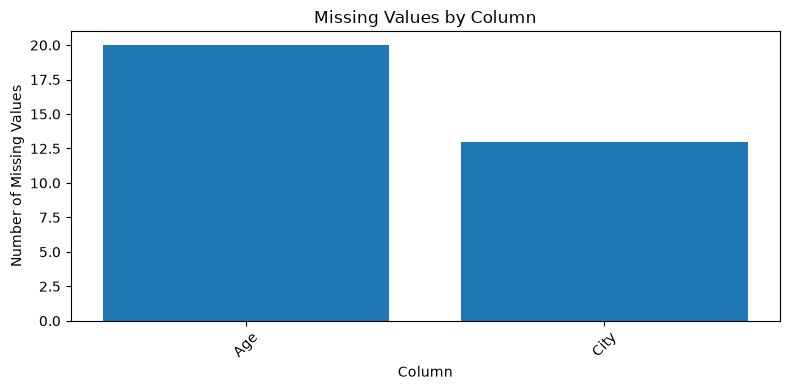

In [24]:
missing_plot = missing_report[missing_report["Missing_Count"] > 0]

if not missing_plot.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(missing_plot["Column"], missing_plot["Missing_Count"])
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


### 5.2 Duplicate Analysis

We check exact duplicate rows separately from repeated `Order_ID` values. Repeated identifiers are not automatically errors because different transaction details can share an order identifier.

In [25]:
exact_duplicates = int(df.duplicated().sum())
order_counts = df["Order_ID"].value_counts()
repeated_order_ids = order_counts[order_counts > 1]

print("Exact duplicate rows:", exact_duplicates)
print("\nRepeated Order_ID values:")
display(repeated_order_ids)


Exact duplicate rows: 0

Repeated Order_ID values:


Order_ID
ORD100050    9
Name: count, dtype: int64

### 5.3 Date Validation

Dates are converted to datetime and checked for invalid values. This is necessary for reliable time-based analysis later.

In [26]:
date_check = pd.to_datetime(df["Order_Date"], errors="coerce")

print("Invalid/missing dates after conversion:", int(date_check.isna().sum()))
print("Earliest order date:", date_check.min())
print("Latest order date:", date_check.max())


Invalid/missing dates after conversion: 0
Earliest order date: 2025-01-01 00:00:00
Latest order date: 2026-01-01 00:00:00


### 5.4 Categorical Consistency

We inspect common categorical fields before cleaning so unexpected values can be seen.

In [27]:
for column in ["Gender", "City", "Product", "Category"]:
    print(f"\n{column}")
    display(df[column].value_counts(dropna=False).head(20))



Gender


Gender
Male      511
Female    489
Name: count, dtype: int64


City


City
Patna        135
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
NaN           13
Name: count, dtype: int64


Product


Product
Mobile    184
Book      178
Laptop    170
Chair     159
Shoes     156
Rice      153
Name: count, dtype: int64


Category


Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64

### 5.5 Outlier Screening

The IQR method is used as an initial screening method. A flagged value is a **potential outlier**, not automatically a mistake. Business context is required before deleting a genuine high-value transaction.

In [28]:
numeric_columns = df.select_dtypes(include=np.number).columns
outlier_rows = []

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df[column] < lower) | (df[column] > upper)).sum())
    outlier_rows.append([column, q1, q3, iqr, lower, upper, count])

outlier_report = pd.DataFrame(
    outlier_rows,
    columns=["Column", "Q1", "Q3", "IQR", "Lower_Bound", "Upper_Bound", "Potential_Outliers"]
)

display(outlier_report)


,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Potential_Outliers
0,Age,30.0000,54.0000,24.00,-6.0000,90.0000,0
1,Quantity,3.0000,8.0000,5.00,-4.5000,15.5000,0
2,Unit_Price,13895.7225,37512.3825,23616.66,-21529.2675,72937.3725,0
3,Total_Sales,47066.6325,203722.8825,156656.25,-187917.7425,438707.2575,19


C:\Users\aaron\AppData\Local\Temp\ipykernel_25348\992510665.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Total_Sales"].dropna(), vert=False)


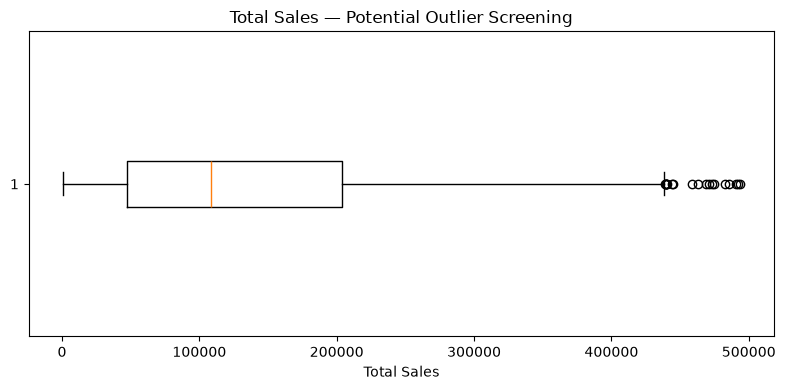

In [29]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["Total_Sales"].dropna(), vert=False)
plt.title("Total Sales — Potential Outlier Screening")
plt.xlabel("Total Sales")
plt.tight_layout()
plt.show()


## 6. Data Cleaning & Transformation

The following decisions are applied:

- Convert `Order_Date` to a proper date type.
- Strip unnecessary whitespace from text fields.
- Fill missing `Age` values with the median.
- Fill missing `City` values with `Unknown`.
- Create `Age_Group` for segmentation.
- Calculate `Sales_Check` using `Quantity × Unit_Price`.
- Create `Sales_Check_Status` to validate `Total_Sales`.
- Create `Transaction_ID` for unique row-level tracking.
- Retain non-identical repeated `Order_ID` records instead of deleting them without evidence.

In [30]:
clean = df.copy()

# Standardize dates
clean["Order_Date"] = pd.to_datetime(clean["Order_Date"], errors="coerce")

# Standardize text fields
text_columns = [
    "Order_ID", "Customer_ID", "Customer_Name",
    "Gender", "City", "Product", "Category"
]
for column in text_columns:
    clean[column] = clean[column].astype("string").str.strip()

# Handle missing values
clean["Age"] = clean["Age"].fillna(clean["Age"].median())
clean["City"] = clean["City"].fillna("Unknown")

# Feature engineering
clean["Age_Group"] = pd.cut(
    clean["Age"],
    bins=[0, 17, 25, 35, 50, 65, np.inf],
    labels=["Under 18", "18-25", "26-35", "36-50", "51-65", "66+"],
    include_lowest=True
)

# Revenue validation
clean["Sales_Check"] = (clean["Quantity"] * clean["Unit_Price"]).round(2)
clean["Sales_Check_Status"] = np.where(
    np.isclose(clean["Sales_Check"], clean["Total_Sales"], atol=0.01),
    "Valid",
    "Mismatch"
)

# Unique transaction identifier
clean["Transaction_ID"] = [f"TXN{i:06d}" for i in range(1, len(clean) + 1)]

clean = clean[
    ["Transaction_ID", "Order_ID", "Order_Date", "Customer_ID", "Customer_Name",
     "Age", "Age_Group", "Gender", "City", "Product", "Category",
     "Quantity", "Unit_Price", "Total_Sales", "Sales_Check", "Sales_Check_Status"]
]

display(clean.head())


,Transaction_ID,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Age_Group,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Sales_Check,Sales_Check_Status
0,TXN000001,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,26-35,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,19808.39,Valid
1,TXN000002,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,51-65,Male,Bengaluru,Book,Education,5,27906.16,139530.80,139530.80,Valid
2,TXN000003,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,51-65,Female,Bengaluru,Book,Education,8,37491.06,299928.48,299928.48,Valid
3,TXN000004,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,51-65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,256872.24,Valid
4,TXN000005,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,36-50,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,140365.90,Valid


## 7. Post-Cleaning Validation

A cleaning workflow must be validated after transformations. We confirm that the identified missing values have been handled, dates are valid, and the sales calculation is consistent.

In [31]:
validation_report = pd.DataFrame({
    "Validation_Check": [
        "Missing Age",
        "Missing City",
        "Invalid Order Dates",
        "Sales Calculation Mismatches",
        "Exact Duplicate Rows",
        "Total Rows",
        "Total Columns"
    ],
    "Result": [
        int(clean["Age"].isna().sum()),
        int(clean["City"].isna().sum()),
        int(clean["Order_Date"].isna().sum()),
        int((clean["Sales_Check_Status"] == "Mismatch").sum()),
        int(clean.duplicated().sum()),
        int(clean.shape[0]),
        int(clean.shape[1])
    ]
})

display(validation_report)


,Validation_Check,Result
0,Missing Age,0
1,Missing City,0
2,Invalid Order Dates,0
3,Sales Calculation Mismatches,0
4,Exact Duplicate Rows,0
5,Total Rows,1000
6,Total Columns,16


In [32]:
print("Sales validation status:")
display(clean["Sales_Check_Status"].value_counts())

print("Age group distribution:")
display(clean["Age_Group"].value_counts().sort_index())


Sales validation status:


Sales_Check_Status
Valid    1000
Name: count, dtype: int64

Age group distribution:


Age_Group
Under 18      0
18-25       158
26-35       219
36-50       316
51-65       307
66+           0
Name: count, dtype: int64

## 8. Before vs After Summary

This table summarizes the effect of the cleaning process.

In [33]:
before_after = pd.DataFrame({
    "Metric": [
        "Rows",
        "Original Columns",
        "Final Columns",
        "Missing Age",
        "Missing City",
        "Exact Duplicate Rows",
        "Sales Mismatches"
    ],
    "Before": [
        len(df),
        len(df.columns),
        "-",
        int(df["Age"].isna().sum()),
        int(df["City"].isna().sum()),
        int(df.duplicated().sum()),
        "-"
    ],
    "After": [
        len(clean),
        "-",
        len(clean.columns),
        int(clean["Age"].isna().sum()),
        int(clean["City"].isna().sum()),
        int(clean.duplicated().sum()),
        int((clean["Sales_Check_Status"] == "Mismatch").sum())
    ]
})

display(before_after)


,Metric,Before,After
0,Rows,1000,1000
1,Original Columns,12,-
2,Final Columns,-,16
3,Missing Age,20,0
4,Missing City,13,0
5,Exact Duplicate Rows,0,0
6,Sales Mismatches,-,0


## 9. Export the Analysis-Ready Dataset

The cleaned dataset and Task 1 documentation are saved into the project folders. These outputs become the inputs for later analysis and dashboard work.

In [34]:
OUTPUT_DIR = PROJECT_ROOT / "output"
DOCS_DIR = PROJECT_ROOT / "docs"

OUTPUT_DIR.mkdir(exist_ok=True)
DOCS_DIR.mkdir(exist_ok=True)

clean.to_csv(OUTPUT_DIR / "sales_cleaned.csv", index=False)
clean.to_excel(OUTPUT_DIR / "sales_cleaned.xlsx", index=False)

data_dictionary.to_csv(DOCS_DIR / "data_dictionary.csv", index=False)
missing_report.to_csv(DOCS_DIR / "data_quality_profile.csv", index=False)
repeated_order_ids.to_csv(DOCS_DIR / "duplicate_order_id_report.csv", header=["Count"])

print("Task 1 deliverables exported successfully.")


Task 1 deliverables exported successfully.


# 10. Final Report & Conclusion

### Key findings

- The dataset contains **1,000 records and 12 original columns**.
- Missing values were identified in `Age` and `City`.
- No exact duplicate rows were found.
- Repeated `Order_ID` values were identified and reviewed rather than blindly deleted.
- Dates were standardized and validated.
- Numerical fields were screened for potential outliers using IQR.
- `Total_Sales` was validated against `Quantity × Unit_Price`.

### Transformations performed

- Date standardization
- Text standardization
- Missing-value handling
- Age-group feature engineering
- Sales calculation validation
- Unique transaction ID creation

### Final outcome

The dataset has been transformed into an **analysis-ready dataset** for the next stage of the ApexPlanet Data Analytics Internship.

### Skills demonstrated

**Python · Pandas · NumPy · Matplotlib · Data Profiling · Data Cleaning · Missing-Value Handling · Duplicate Analysis · Outlier Detection · Feature Engineering · Data Validation · Jupyter**

**Task 1 — Data Immersion & Wrangling: Completed**
